In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

from plotting import *

2026-07-27 13:15:05.196381: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


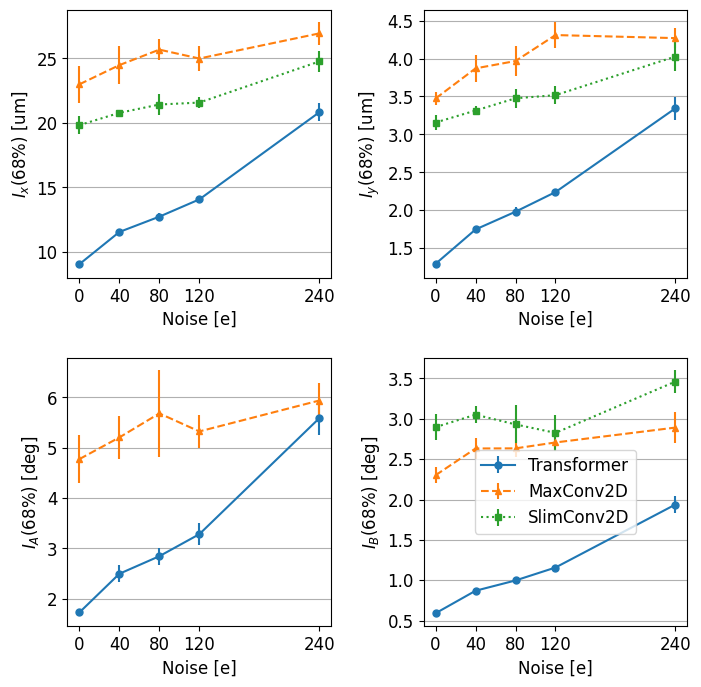

In [2]:
noise = [0,40,80,120,240]

fig, ax = plt.subplots(2,2,figsize=(8,8),gridspec_kw={'wspace': 0.35,'hspace':0.3})

labels = ["Transformer","MaxConv2D","SlimConv2D"]

for i,t in enumerate(["Transformer","MaxConv2D_SQ", "SlimConv2D_SQ"]):

    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if 'MaxConv2D' in t:
        marker = '^'
        ls = '--'
        color='tab:orange'
        
    if 'SlimConv2D' in t:
        marker = 's'
        ls = ':'
        color = 'tab:green'

    x_mean = []
    y_mean = []
    B_mean = []
    A_mean = []

    x_std = []
    y_std = []
    B_std = []
    A_std = []
    
    for n in noise:
        name = t + "_" + str(n) + "e_2bit"

        if "Transformer" in t:
            name = t + str(n) + "e_2bit"

        df = pd.read_parquet("avg_res_2s_"+name+".parquet")

        x_mean += [np.mean(df['up68_x'] + df['down68_x'])]
        y_mean += [np.mean(df['up68_y'] + df['down68_y'])]
        B_mean += [np.mean(df['up68_B'] + df['down68_B'])]

        x_std += [np.std(df['up68_x'] + df['down68_x'])]
        y_std += [np.std(df['up68_y'] + df['down68_y'])]
        B_std += [np.std(df['up68_B'] + df['down68_B'])]

        if "Slim" not in t:
            A_mean += [np.mean(df['up68_A'] + df['down68_A'])]
            A_std += [np.std(df['up68_A'] + df['down68_A'])]

    ax[0][0].set_ylabel("$I_x (68\%)$ [um]")
    ax[0][0].errorbar(x=noise, y=x_mean, yerr=x_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    ax[0][1].set_ylabel("$I_y (68\%)$ [um]")
    ax[0][1].errorbar(x=noise, y=y_mean, yerr=y_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    if "Slim" not in t:
        ax[1][0].set_ylabel("$I_A(68\%)$ [deg]")
        ax[1][0].errorbar(x=noise, y=A_mean, yerr=A_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    
    ax[1][1].set_ylabel("$I_B (68\%)$ [deg]")
    ax[1][1].errorbar(x=noise, y=B_mean, yerr=B_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

ax[1][1].legend()
ax[0][0].set_xlabel('Noise [e]')
ax[1][0].set_xlabel('Noise [e]')
ax[0][1].set_xlabel('Noise [e]')
ax[1][1].set_xlabel('Noise [e]')

ax[0][0].set_xticks(noise);
ax[0][1].set_xticks(noise);
ax[1][0].set_xticks(noise);
ax[1][1].set_xticks(noise);

ax[0][0].grid(axis='y')
ax[0][1].grid(axis='y')
ax[1][0].grid(axis='y')
ax[1][1].grid(axis='y')

plt.savefig('results3.png',bbox_inches='tight')
plt.savefig('results3.pdf',bbox_inches='tight')

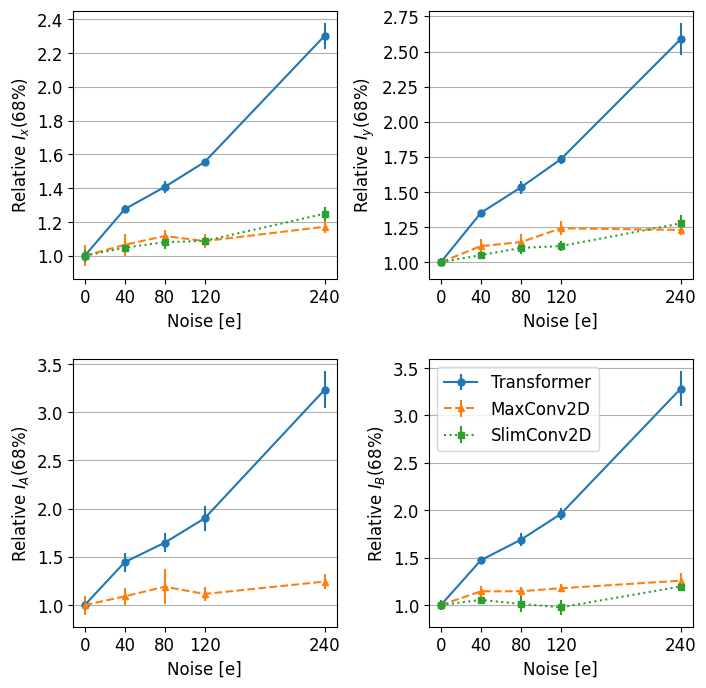

In [3]:
noise = [0,40,80,120,240]

fig, ax = plt.subplots(2,2,figsize=(8,8),gridspec_kw={'wspace': 0.35,'hspace':0.3})

labels = ["Transformer","MaxConv2D","SlimConv2D"]

for i,t in enumerate(["Transformer","MaxConv2D_SQ", "SlimConv2D_SQ"]):

    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if 'MaxConv2D' in t:
        marker = '^'
        ls = '--'
        color='tab:orange'
        
    if 'SlimConv2D' in t:
        marker = 's'
        ls = ':'
        color = 'tab:green'

    x_mean = []
    y_mean = []
    B_mean = []
    A_mean = []

    x_std = []
    y_std = []
    B_std = []
    A_std = []
    
    for n in noise:
        name = t + "_" + str(n) + "e_2bit"

        if "Transformer" in t:
            name = t + str(n) + "e_2bit"

        df = pd.read_parquet("avg_res_2s_"+name+".parquet")

        x_mean += [np.mean(df['up68_x'] + df['down68_x'])]
        y_mean += [np.mean(df['up68_y'] + df['down68_y'])]
        B_mean += [np.mean(df['up68_B'] + df['down68_B'])]

        x_std += [np.std(df['up68_x'] + df['down68_x'])]
        y_std += [np.std(df['up68_y'] + df['down68_y'])]
        B_std += [np.std(df['up68_B'] + df['down68_B'])]

        if "Slim" not in t:
            A_mean += [np.mean(df['up68_A'] + df['down68_A'])]
            A_std += [np.std(df['up68_A'] + df['down68_A'])]

    x_std = x_std / x_mean[0]
    x_mean = x_mean / x_mean[0]

    y_std = y_std / y_mean[0]
    y_mean = y_mean / y_mean[0]
    
    B_std = B_std / B_mean[0]
    B_mean = B_mean / B_mean[0]
    
    if "Slim" not in t:
        A_std = A_std / A_mean[0]
        A_mean = A_mean / A_mean[0]
        

    ax[0][0].set_ylabel("Relative $I_x (68\%)$")
    ax[0][0].errorbar(x=noise, y=x_mean, yerr=x_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    ax[0][1].set_ylabel("Relative $I_y (68\%)$")
    ax[0][1].errorbar(x=noise, y=y_mean, yerr=y_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    if "Slim" not in t:
        ax[1][0].set_ylabel("Relative $I_A(68\%)$")
        ax[1][0].errorbar(x=noise, y=A_mean, yerr=A_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    
    ax[1][1].set_ylabel("Relative $I_B (68\%)$")
    ax[1][1].errorbar(x=noise, y=B_mean, yerr=B_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

ax[1][1].legend()
ax[0][0].set_xlabel('Noise [e]')
ax[1][0].set_xlabel('Noise [e]')
ax[0][1].set_xlabel('Noise [e]')
ax[1][1].set_xlabel('Noise [e]')

ax[0][0].set_xticks(noise);
ax[0][1].set_xticks(noise);
ax[1][0].set_xticks(noise);
ax[1][1].set_xticks(noise);

ax[0][0].grid(axis='y')
ax[0][1].grid(axis='y')
ax[1][0].grid(axis='y')
ax[1][1].grid(axis='y')

MaxConv2D_SQ
SlimConv2D_SQ
Geometric
Geometric_better


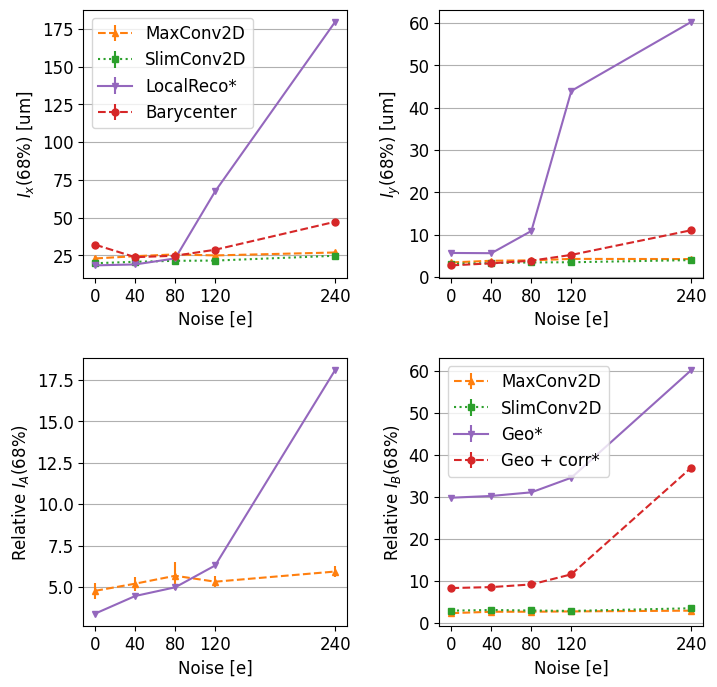

In [4]:
noise = [0,40,80,120,240]

fig, ax = plt.subplots(2,2,figsize=(8,8),gridspec_kw={'wspace': 0.35,'hspace':0.3})

labels = ["MaxConv2D","SlimConv2D","LocalReco*","Barycenter"]

for i,t in enumerate(["MaxConv2D_SQ","SlimConv2D_SQ","LocalReco","Barycenter"]):

    marker = 'v'
    color = "tab:purple"
    ls = '-'

    if 'MaxConv2D' in t:
        marker = '^'
        ls = '--'
        color='tab:orange'

    if 'Barycenter' in t:
        marker = 'o'
        ls = '--'
        color='tab:red'
        
    if 'SlimConv2D' in t:
        marker = 's'
        ls = ':'
        color = 'tab:green'

    x_mean = []
    y_mean = []
    B_mean = []
    A_mean = []

    x_std = []
    y_std = []
    B_std = []
    A_std = []
    
    for n in noise:

        name = t + "_" + str(n) + "e"
        
        if 'SQ' in t:
            name = t + "_" + str(n) + "e_2bit"

        if "Transformer" in t:
            name = t + str(n) + "e_2bit"

        df = pd.read_parquet("avg_res_2s_"+name+".parquet")

        x_mean += [np.mean(df['up68_x'] + df['down68_x'])]
        y_mean += [np.mean(df['up68_y'] + df['down68_y'])]

        x_std += [np.std(df['up68_x'] + df['down68_x'])]
        y_std += [np.std(df['up68_y'] + df['down68_y'])]

        if "LocalReco" not in t and "Barycenter" not in t:
            B_mean += [np.mean(df['up68_B'] + df['down68_B'])]
            B_std += [np.std(df['up68_B'] + df['down68_B'])]

        if "Slim" not in t:
            A_mean += [np.mean(df['up68_A'] + df['down68_A'])]
            A_std += [np.std(df['up68_A'] + df['down68_A'])]

    ax[0][0].set_ylabel("$I_x (68\%)$ [um]")
    ax[0][0].errorbar(x=noise, y=x_mean, yerr=x_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    ax[0][1].set_ylabel("$I_y (68\%)$ [um]")
    ax[0][1].errorbar(x=noise, y=y_mean, yerr=y_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

labels = ["MaxConv2D","SlimConv2D","Geo*","Geo + corr*"]

for i,t in enumerate(["MaxConv2D_SQ","SlimConv2D_SQ","Geometric","Geometric_better"]):

    print(t)
    
    marker = 'v'
    color = "tab:purple"
    ls = '-'

    if 'MaxConv2D' in t:
        marker = '^'
        ls = '--'
        color='tab:orange'

    if 'better' in t:
        marker = 'o'
        ls = '--'
        color='tab:red'
        
    if 'SlimConv2D' in t:
        marker = 's'
        ls = ':'
        color = 'tab:green'

    x_mean = []
    y_mean = []
    B_mean = []
    A_mean = []

    x_std = []
    y_std = []
    B_std = []
    A_std = []
    
    for n in noise:

        name = t + "_" + str(n) + "e"
        
        if 'SQ' in t:
            name = t + "_" + str(n) + "e_2bit"

        if "Transformer" in t:
            name = t + str(n) + "e_2bit"

        df = pd.read_parquet("avg_res_2s_"+name+".parquet")

        B_mean += [np.mean(df['up68_B'] + df['down68_B'])]
        B_std += [np.std(df['up68_B'] + df['down68_B'])]

        if "Slim" not in t and "Geometric_better" not in t:
            A_mean += [np.mean(df['up68_A'] + df['down68_A'])]
            A_std += [np.std(df['up68_A'] + df['down68_A'])]

    if "Slim" not in t and "Geometric_better" not in t:
        ax[1][0].set_ylabel("Relative $I_A(68\%)$")
        ax[1][0].errorbar(x=noise, y=A_mean, yerr=A_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)
    
    ax[1][1].set_ylabel("Relative $I_B (68\%)$")
    ax[1][1].errorbar(x=noise, y=B_mean, yerr=B_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)


ax[0][0].legend()
ax[1][1].legend()
ax[0][0].set_xlabel('Noise [e]')
ax[1][0].set_xlabel('Noise [e]')
ax[0][1].set_xlabel('Noise [e]')
ax[1][1].set_xlabel('Noise [e]')

ax[0][0].set_xticks(noise);
ax[0][1].set_xticks(noise);
ax[1][0].set_xticks(noise);
ax[1][1].set_xticks(noise);

ax[0][0].grid(axis='y')
ax[0][1].grid(axis='y')
ax[1][0].grid(axis='y')
ax[1][1].grid(axis='y')

plt.savefig('results4.png',bbox_inches='tight')
plt.savefig('results4.pdf',bbox_inches='tight')


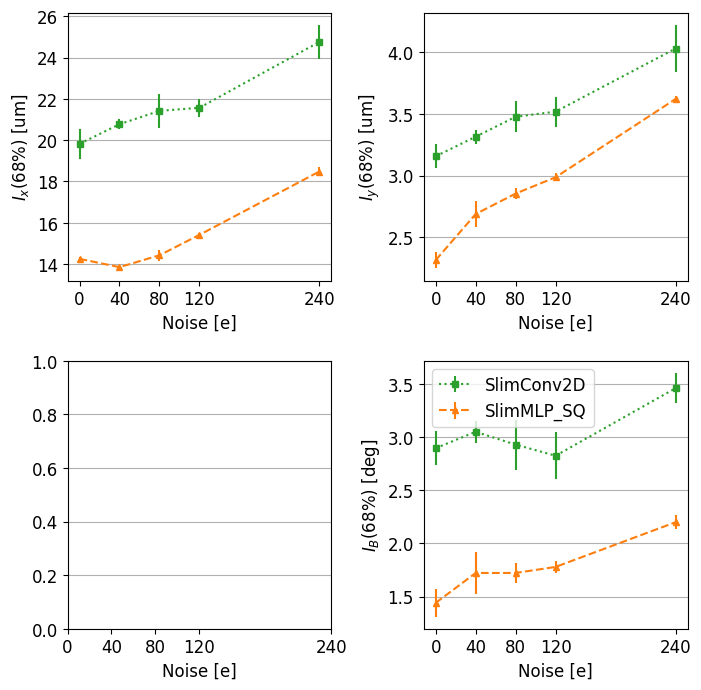

In [6]:
noise = [0,40,80,120,240]

fig, ax = plt.subplots(2,2,figsize=(8,8),gridspec_kw={'wspace': 0.35,'hspace':0.3})

labels = ["SlimConv2D","SlimMLP_SQ"]

for i,t in enumerate(["SlimConv2D_SQ","SlimMLP_SQ"]):

    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if 'SlimMLP' in t:
        marker = '^'
        ls = '--'
        color='tab:orange'
        
    if 'SlimConv2D' in t:
        marker = 's'
        ls = ':'
        color = 'tab:green'

    x_mean = []
    y_mean = []
    B_mean = []
    A_mean = []

    x_std = []
    y_std = []
    B_std = []
    A_std = []
    
    for n in noise:
        name = t + "_" + str(n) + "e_2bit"

        if "Transformer" in t:
            name = t + str(n) + "e_2bit"

        df = pd.read_parquet("avg_res_2s_"+name+".parquet")

        x_mean += [np.mean(df['up68_x'] + df['down68_x'])]
        y_mean += [np.mean(df['up68_y'] + df['down68_y'])]
        B_mean += [np.mean(df['up68_B'] + df['down68_B'])]

        x_std += [np.std(df['up68_x'] + df['down68_x'])]
        y_std += [np.std(df['up68_y'] + df['down68_y'])]
        B_std += [np.std(df['up68_B'] + df['down68_B'])]

        if "Slim" not in t:
            A_mean += [np.mean(df['up68_A'] + df['down68_A'])]
            A_std += [np.std(df['up68_A'] + df['down68_A'])]

    ax[0][0].set_ylabel("$I_x (68\%)$ [um]")
    ax[0][0].errorbar(x=noise, y=x_mean, yerr=x_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    ax[0][1].set_ylabel("$I_y (68\%)$ [um]")
    ax[0][1].errorbar(x=noise, y=y_mean, yerr=y_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    if "Slim" not in t:
        ax[1][0].set_ylabel("$I_A(68\%)$ [deg]")
        ax[1][0].errorbar(x=noise, y=A_mean, yerr=A_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    
    ax[1][1].set_ylabel("$I_B (68\%)$ [deg]")
    ax[1][1].errorbar(x=noise, y=B_mean, yerr=B_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

ax[1][1].legend()
ax[0][0].set_xlabel('Noise [e]')
ax[1][0].set_xlabel('Noise [e]')
ax[0][1].set_xlabel('Noise [e]')
ax[1][1].set_xlabel('Noise [e]')

ax[0][0].set_xticks(noise);
ax[0][1].set_xticks(noise);
ax[1][0].set_xticks(noise);
ax[1][1].set_xticks(noise);

ax[0][0].grid(axis='y')
ax[0][1].grid(axis='y')
ax[1][0].grid(axis='y')
ax[1][1].grid(axis='y')


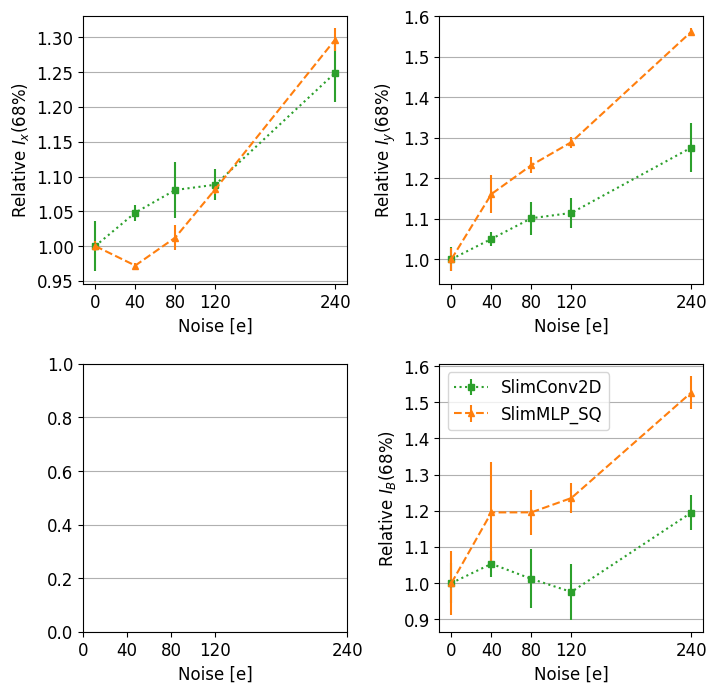

In [7]:
noise = [0,40,80,120,240]

fig, ax = plt.subplots(2,2,figsize=(8,8),gridspec_kw={'wspace': 0.35,'hspace':0.3})

labels = ["SlimConv2D","SlimMLP_SQ"]

for i,t in enumerate(["SlimConv2D_SQ","SlimMLP_SQ"]):

    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if 'SlimMLP' in t:
        marker = '^'
        ls = '--'
        color='tab:orange'
        
    if 'SlimConv2D' in t:
        marker = 's'
        ls = ':'
        color = 'tab:green'

    x_mean = []
    y_mean = []
    B_mean = []
    A_mean = []

    x_std = []
    y_std = []
    B_std = []
    A_std = []
    
    for n in noise:
        name = t + "_" + str(n) + "e_2bit"

        if "Transformer" in t:
            name = t + str(n) + "e_2bit"

        df = pd.read_parquet("avg_res_2s_"+name+".parquet")

        x_mean += [np.mean(df['up68_x'] + df['down68_x'])]
        y_mean += [np.mean(df['up68_y'] + df['down68_y'])]
        B_mean += [np.mean(df['up68_B'] + df['down68_B'])]

        x_std += [np.std(df['up68_x'] + df['down68_x'])]
        y_std += [np.std(df['up68_y'] + df['down68_y'])]
        B_std += [np.std(df['up68_B'] + df['down68_B'])]

        if "Slim" not in t:
            A_mean += [np.mean(df['up68_A'] + df['down68_A'])]
            A_std += [np.std(df['up68_A'] + df['down68_A'])]

    x_std = x_std / x_mean[0]
    x_mean = x_mean / x_mean[0]

    y_std = y_std / y_mean[0]
    y_mean = y_mean / y_mean[0]
    
    B_std = B_std / B_mean[0]
    B_mean = B_mean / B_mean[0]
    
    if "Slim" not in t:
        A_std = A_std / A_mean[0]
        A_mean = A_mean / A_mean[0]
        

    ax[0][0].set_ylabel("Relative $I_x (68\%)$")
    ax[0][0].errorbar(x=noise, y=x_mean, yerr=x_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    ax[0][1].set_ylabel("Relative $I_y (68\%)$")
    ax[0][1].errorbar(x=noise, y=y_mean, yerr=y_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    if "Slim" not in t:
        ax[1][0].set_ylabel("Relative $I_A(68\%)$")
        ax[1][0].errorbar(x=noise, y=A_mean, yerr=A_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    
    ax[1][1].set_ylabel("Relative $I_B (68\%)$")
    ax[1][1].errorbar(x=noise, y=B_mean, yerr=B_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

ax[1][1].legend()
ax[0][0].set_xlabel('Noise [e]')
ax[1][0].set_xlabel('Noise [e]')
ax[0][1].set_xlabel('Noise [e]')
ax[1][1].set_xlabel('Noise [e]')

ax[0][0].set_xticks(noise);
ax[0][1].set_xticks(noise);
ax[1][0].set_xticks(noise);
ax[1][1].set_xticks(noise);

ax[0][0].grid(axis='y')
ax[0][1].grid(axis='y')
ax[1][0].grid(axis='y')
ax[1][1].grid(axis='y')